# Batch-wise causarray analysis: Replogle K562

This tutorial analyses a subset of the [Replogle et al. CRISPRi screen](https://doi.org/10.1016/j.cell.2022.05.013), compares adjusted log-fold changes with a marginal Wilcoxon analysis, and checks propensity-score support.

`1_prep_tutorial_data.py` prepares raw counts for the most abundant perturbations and a shared non-targeting control pool. `gcate_lfc_batch` fits subsets of perturbations with shared controls to limit the size of each fit.

The workflow is **prepare inputs → select a factor rank → fit batches → check propensity support and refit where it fails → read the effects**. Support is checked before the effects are read, because an arm whose inverse-probability weights collapse can report a large discovery count that reflects the weights rather than the biology. The comparison and propensity sections use `crispyx` and local caches; recompute dependent caches after changing data, settings, or package versions.


In [1]:
import sys
sys.path.insert(0, '../../..')

import time
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scanpy as sc

from causarray import prep_causarray_data, gcate_lfc_batch, align_test_mask
from causarray.gcate import plot_r

import causarray
print('causarray version:', causarray.__version__)

# Analysis-wide significance threshold, used by the diagnostics and the results.
FDR = 0.05

causarray version: 0.0.10


## 1. Load data

Load the subset prepared by `1_prep_tutorial_data.py`. The output reports its dimensions and treatment-group sizes.


In [2]:
adata = sc.read_h5ad('data/replogle_subset.h5ad')
print(adata)

CTRL_LABEL = adata.uns['ctrl_label']   # 'non-targeting'
PERT_COL   = adata.uns['pert_col']     # 'gene'

vc = adata.obs[PERT_COL].value_counts()
print(f'\nCtrl cells  : {vc[CTRL_LABEL]}')
print(f'Pert cells  : {vc.drop(CTRL_LABEL).sum():,}  across {len(vc) - 1} perturbations')
print(f'Cells/pert  : median {vc.drop(CTRL_LABEL).median():.0f}, '
      f'range {vc.drop(CTRL_LABEL).min()}-{vc.drop(CTRL_LABEL).max()}')


AnnData object with n_obs × n_vars = 79865 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells'
    uns: 'ctrl_label', 'pert_col'

Ctrl cells  : 2000
Pert cells  : 77,865  across 200 perturbations
Cells/pert  : median 346, range 273-1996


## 2. Prepare causarray inputs

`prep_causarray_data` caps extreme counts, adds an intercept, and includes standardized log-library size in the propensity design `X_A`. The outcome matrix contains counts, not log-normalized expression.


In [3]:
Y_raw = adata.X.toarray() if sp.issparse(adata.X) else np.array(adata.X)
Y = pd.DataFrame(Y_raw, columns=adata.var_names.tolist())
del Y_raw

A = (pd.get_dummies(adata.obs[PERT_COL].astype(str), drop_first=False)
       .drop(columns=[CTRL_LABEL]))

Y, A, X, X_A = prep_causarray_data(Y, A)

print(f'Y : {Y.shape}  (cells x genes)')
print(f'A : {A.shape}  (cells x perturbations)')
print(f'X : {X.shape}  X_A : {X_A.shape}')


Y : (79865, 8563)  (cells x genes)
A : (79865, 200)  (cells x perturbations)
X : (79865, 1)  X_A : (79865, 2)


## 3. Number of latent factors

The JIC table from `2_estimate_r.py` evaluates candidate ranks on a control-heavy subsample of the raw-count data. Select the rank with the smallest JIC and inspect nearby ranks when the curve is flat. Subsampling reduces computation; it need not select the same rank as a full-data fit.

The legacy fallback table uses different preprocessing. Treat it as a historical illustration and recompute the raw-count table before using its rank for a new analysis. A flat JIC curve does not establish that confounding is absent.


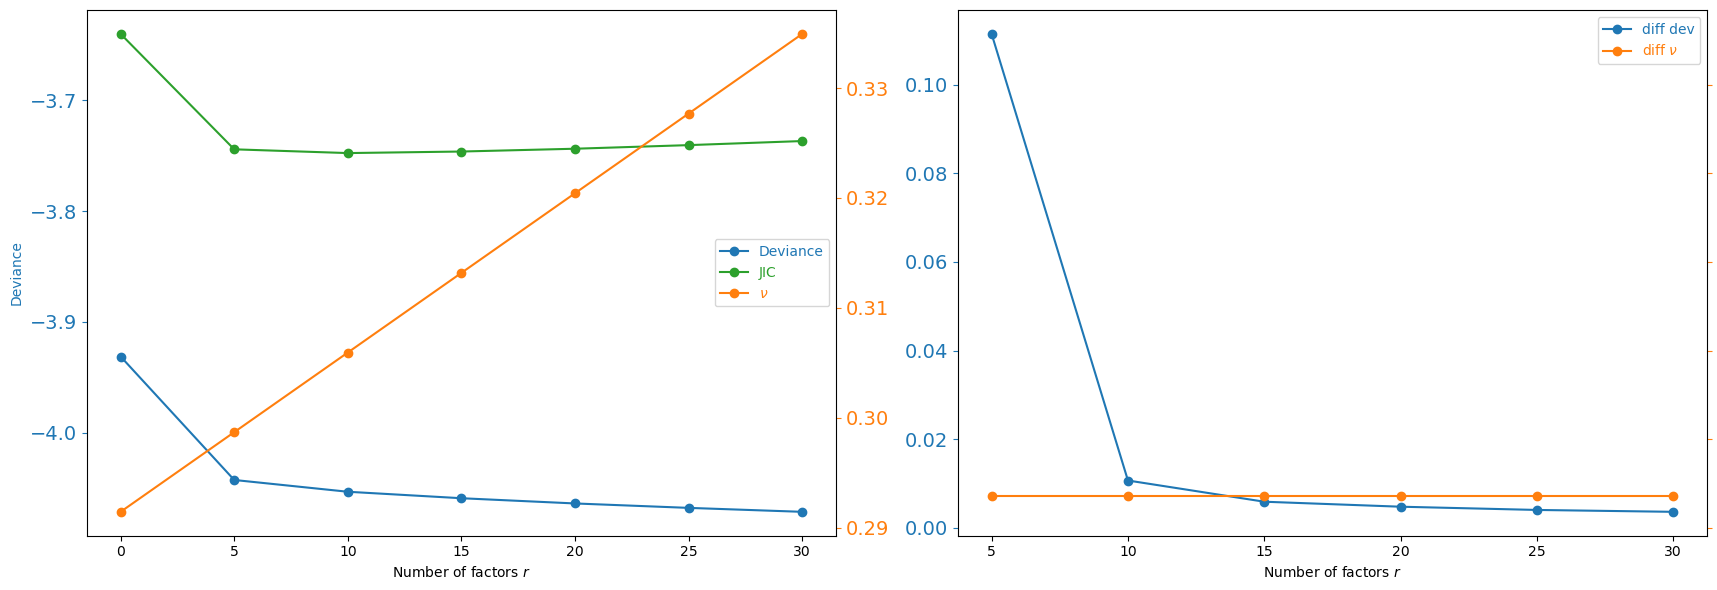


Selected r = 10  (min JIC)
 r  deviance       nu       JIC     time_s
 0 -3.931351 0.291434 -3.639917  34.124589
 5 -4.042865 0.298683 -3.744181 105.917385
10 -4.053505 0.305933 -3.747573 110.224151
15 -4.059356 0.313183 -3.746173 113.079680
20 -4.064079 0.320432 -3.743646 120.366626
25 -4.068070 0.327682 -3.740389 124.748423
30 -4.071637 0.334931 -3.736706 144.562551


In [4]:
# JIC table on the raw counts (2_estimate_r.py); falls back to the pre-0.0.10
# table computed on the log-normalised copy only if the new one is missing.
r_path = Path('results/replogle-r.csv') if Path('results/replogle-r.csv').exists() else Path('results/replogle-r-legacy.csv')
if r_path.name == 'results/replogle-r-legacy.csv':
    print('Note: JIC table from the pre-0.0.10 (log-normalised) run; run 2_estimate_r.py to recompute it.')
df_r = pd.read_csv(r_path)
fig = plot_r(df_r)
plt.tight_layout()
plt.show()

best_r = int(df_r.loc[df_r['JIC'].idxmin(), 'r'])
print(f'\nSelected r = {best_r}  (min JIC)')
print(df_r.to_string(index=False))


## 4. Batch fitting with `gcate_lfc_batch`

`batch_size` controls the number of perturbations per fit; `max_cells` caps perturbed cells and `n_ctrl` sets the shared control pool. The function distributes perturbations across batches and writes results to `cache_path` so a run can resume.

Use a fresh cache when changing the data, rank, fitting settings, or inference version. A cached result is not validation of the current implementation.


In [5]:
R = best_r

t0 = time.perf_counter()
df_res = gcate_lfc_batch(
    Y, X, A, R,
    W_A=X_A,
    batch_size=15,
    max_cells=2000,
    n_ctrl=2000,
    family='nb',
    cache_path='results/replogle_results.h5',
    random_state=0,
    verbose=True,
    gcate_kwargs=dict(
        kwargs_es_1=dict(rel_tol=2e-4, max_iters=30),
        kwargs_es_2=dict(rel_tol=2e-4, max_iters=30),
    ),
)
t_total = time.perf_counter() - t0

print(f'\nTotal wall time: {t_total/60:.1f} min')
print(f'Result shape   : {df_res.shape}')
df_res.head()


[gcate_lfc_batch] Resuming: 14 batches already cached in 'results/replogle_results.h5'
'Pre-estimating dispersion on ctrl cell subsample...'


GCATE batches:   0%|          | 0/14 [00:00<?, ?batch/s]

GCATE batches: 100%|██████████| 14/14 [00:00<00:00, 134371.30batch/s]


Total wall time: 0.1 min
Result shape   : (1712600, 22)


,gene_names,tau,std,log2fc,log2fc_se,stat,rej,pvalue,padj,pvalue_emp_null_adj,...,n_control,count_treated,count_control,mean_control,mean_treated,estimable,var_floored,std_raw,trt,batch
0,LINC01409,0.000000,inf,0.000000,inf,NaN,0.0,NaN,NaN,NaN,...,2000,12.0,248.0,0.119990,0.115295,True,False,inf,AATF,0
1,LINC01128,-0.095624,0.376348,-0.137957,0.542956,-0.254084,0.0,0.799456,0.867872,0.910281,...,2000,20.0,546.0,0.265424,0.241219,True,False,0.376348,AATF,0
2,NOC2L,0.059683,0.106689,0.086105,0.153919,0.559414,0.0,0.575939,0.779285,0.662723,...,2000,219.0,4278.0,2.066363,2.193445,True,False,0.106689,AATF,0
3,KLHL17,-0.243954,0.339267,-0.351951,0.489458,-0.719063,0.0,0.472183,0.735848,0.669826,...,2000,16.0,300.0,0.145126,0.113710,True,False,0.339267,AATF,0
4,HES4,0.338578,0.247739,0.488465,0.357412,1.366673,0.0,0.171875,0.501027,0.326743,...,2000,30.0,499.0,0.243046,0.340982,True,False,0.247739,AATF,0


## 5. Propensity-score diagnostics and refit

Read this before the effects. An arm whose propensity model separates it from the controls has inverse-probability weights concentrated on a few cells, and its discovery count then reflects the weights rather than the biology.

The focal batch prepared by `4_cache_propensity_batch.py` carries its treatment matrix and propensity design, so the diagnosis and the repair can both be run here. `5_refit_propensity.py` applies the same procedure to all 14 batches to produce the results this notebook reads.

In [6]:
from causarray import (estimate_propensity_scores, refit_propensity_scores,
                       summarize_propensity_scores, tune_penalty_factor)

ps_cache_path = Path('results/replogle_propensity_batch12.npz')
ps_scores_path = Path('results/replogle_propensity_batch12_selected_scores.npz')

# The focal batch stores its own treatment matrix and propensity design:
# intercept, standardized log library size, then the batch's latent factors.
_focal = np.load(ps_cache_path, allow_pickle=True)
A_focal = _focal['A'].astype(float)
W_A_focal = _focal['X_A'].astype(float)
focal_perts = _focal['perturbations'].astype(str).tolist()
focal_covariates = (['intercept', 'log_library_size']
                    + [f'U{k + 1}' for k in range(W_A_focal.shape[1] - 2)])

pi_before = estimate_propensity_scores(
    A_focal, W_A_focal, K=1, C=1.0, class_weight=None, clip=None, random_state=0)
support_before = summarize_propensity_scores(
    A_focal, pi_before, treatment_names=focal_perts, clip_bounds=None).set_index('treatment')
display(support_before[['prevalence', 'auc', 'overlap_ratio',
                        'ess_treated_fraction', 'ess_control_fraction']]
        .sort_values('overlap_ratio').head(8).round(3))

,prevalence,auc,overlap_ratio,ess_treated_fraction,ess_control_fraction
treatment,,,,,
SUPT5H,0.070,1.000,0.000,0.940,0.998
SUPT6H,0.046,1.000,0.001,0.955,0.999
SRRT,0.055,0.992,0.037,0.584,0.821
TIMM23B,0.078,0.975,0.082,0.115,0.411
SSRP1,0.093,0.960,0.130,0.113,0.329
TSR2,0.083,0.778,0.439,0.161,0.996
TRRAP,0.063,0.800,0.520,0.559,0.995
SNRPG,0.068,0.517,0.635,0.926,1.000


weakest overlap: ['SUPT5H', 'SUPT6H', 'SRRT', 'TIMM23B']


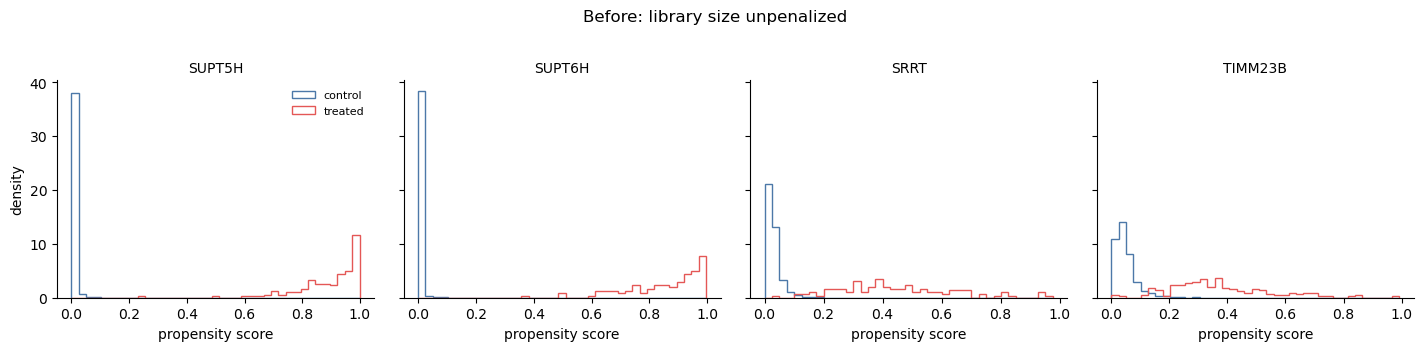

In [7]:
# The four arms with the weakest overlap, before any repair.
ps_focus = support_before.nsmallest(4, 'overlap_ratio').index.tolist()
print('weakest overlap:', ps_focus)

def overlap_panels(pi, title):
    ctrl_mask = A_focal.sum(axis=1) == 0
    fig, axes = plt.subplots(1, len(ps_focus), figsize=(3.6 * len(ps_focus), 3.4), sharey=True)
    for ax, pert in zip(np.atleast_1d(axes), ps_focus):
        j = focal_perts.index(pert)
        treated = A_focal[:, j] == 1
        hi = max(pi[ctrl_mask | treated, j].max(), 1e-3)
        bins = np.linspace(0, hi, 40)
        ax.hist(pi[ctrl_mask, j], bins=bins, density=True, histtype='step',
                color='#4c78a8', label='control')
        ax.hist(pi[treated, j], bins=bins, density=True, histtype='step',
                color='#e45756', label='treated')
        ax.set_title(pert, fontsize=10)
        ax.set_xlabel('propensity score')
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
    np.atleast_1d(axes)[0].set_ylabel('density')
    np.atleast_1d(axes)[0].legend(frameon=False, fontsize=8)
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

overlap_panels(pi_before, 'Before: library size unpenalized')

#### Tuning the library-size penalty

`prep_causarray_data` appends standardized log library size to `X_A`. For a few arms it differs so strongly between the perturbed and control cells that the propensity model can tell them apart almost perfectly, and the weights then rest on a handful of cells. Measured library size mixes capture depth with total RNA content, and these data do not identify which of the two drives a given arm's shift, so how much to adjust for it is a modelling choice rather than a settled one.

`tune_penalty_factor` penalizes **that coefficient alone**, and only for arms failing a pre-specified support check. Dropping the covariate is the infinite-penalty limit, so it bounds what any finite factor can achieve: the search evaluates that endpoint first and reports an arm as infeasible rather than exhausting a grid. Among factors meeting the target it returns the smallest, so the covariate keeps as much of its adjustment role as the data support.

Target a monotone metric. `overlap_ratio` and `auc` move monotonically with the penalty; `ess_treated_fraction` does not, because a completely separated arm has near-uniform weights and a deceptively high ESS that *falls* as the penalty restores genuine overlap. It is used to trigger and to report, not as the target.

In [8]:
penalty_factors, tuning_report = tune_penalty_factor(
    A_focal, W_A_focal, 'log_library_size',
    treatment_names=focal_perts, covariate_names=focal_covariates,
    trigger={'auc_gt': 0.9, 'ess_treated_fraction_lt': 0.5},
    target={'overlap_ratio_gt': 0.3},
    K=1, C=1.0, class_weight=None, random_state=0, verbose=True,
)
display(tuning_report[['treatment', 'penalty_factor', 'feasible', 'n_fits',
                       'overlap_ratio_unpenalized', 'overlap_ratio_chosen',
                       'overlap_ratio_dropped', 'auc_unpenalized', 'auc_chosen']]
        .sort_values('penalty_factor', ascending=False).round(3))

[tune_penalty_factor] 6 treatments triggered, 6 feasible, 42 fits


,treatment,penalty_factor,feasible,n_fits,overlap_ratio_unpenalized,overlap_ratio_chosen,overlap_ratio_dropped,auc_unpenalized,auc_chosen
2,SUPT5H,1154.782,True,8,0.000,0.306,0.340,1.000,0.779
3,SUPT6H,177.828,True,8,0.001,0.324,0.483,1.000,0.860
0,SRRT,48.697,True,8,0.037,0.324,0.742,0.992,0.900
1,SSRP1,36.517,True,8,0.130,0.331,0.619,0.960,0.874
4,TIMM23B,31.623,True,8,0.082,0.340,0.671,0.975,0.887
5,TSR2,1.000,True,2,0.439,0.439,0.722,0.778,0.778


,penalty,overlap before,overlap after,AUC before,AUC after,treated ESS before,treated ESS after
SUPT5H,1154.782,0.000,0.306,1.000,0.779,0.940,0.248
SUPT6H,177.828,0.001,0.324,1.000,0.860,0.955,0.268
SRRT,48.697,0.037,0.324,0.992,0.900,0.584,0.850
TIMM23B,31.623,0.082,0.340,0.975,0.887,0.115,0.699


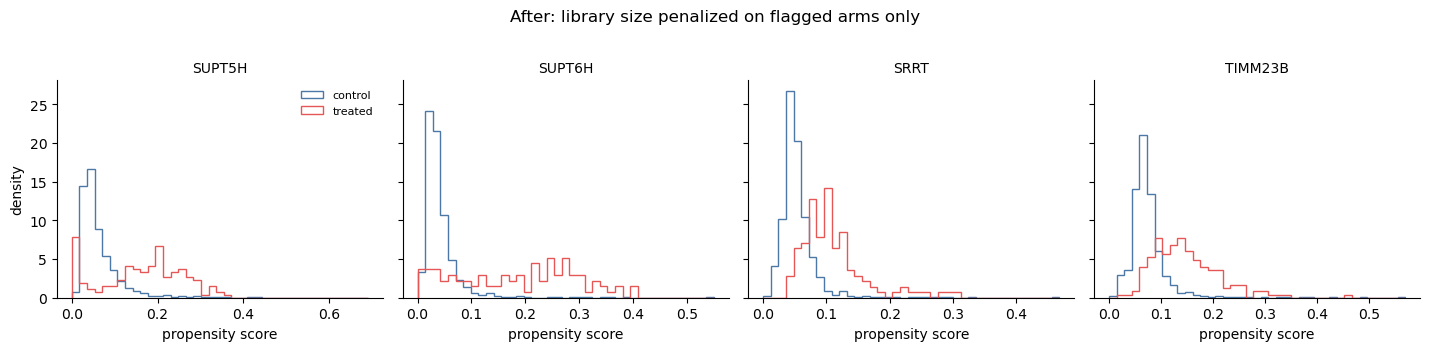

In [9]:
pi_after, refit_audit = refit_propensity_scores(
    A_focal, W_A_focal, pi_hat=pi_before.copy(),
    treatment_names=focal_perts, covariate_names=focal_covariates,
    penalty_factors_by_treatment=penalty_factors,
    K=1, C=1.0, class_weight=None, clip=None, random_state=0)

support_after = summarize_propensity_scores(
    A_focal, pi_after, treatment_names=focal_perts, clip_bounds=None).set_index('treatment')
comparison = pd.DataFrame({
    'penalty': pd.Series({k: v['log_library_size'] for k, v in penalty_factors.items()}),
    'overlap before': support_before['overlap_ratio'],
    'overlap after': support_after['overlap_ratio'],
    'AUC before': support_before['auc'],
    'AUC after': support_after['auc'],
    'treated ESS before': support_before['ess_treated_fraction'],
    'treated ESS after': support_after['ess_treated_fraction'],
}).fillna({'penalty': 1.0}).loc[ps_focus].round(3)
display(comparison)

overlap_panels(pi_after, 'After: library size penalized on flagged arms only')

## 6. Results

### 5.1 Discovery summary


In [10]:
sig = df_res[df_res['padj'] < FDR]

print(f'Significant (padj < {FDR}): {len(sig):,} gene x pert pairs')
print(f'  Perturbations with >= 1 hit: {sig["trt"].nunique()}')
print(f'  Unique genes affected      : {sig["gene_names"].nunique():,}')

disc_per_pert = sig.groupby('trt').size().sort_values(ascending=False)
print(f'\nTop-10 perts by discovery count:')
print(disc_per_pert.head(10).to_string())


Significant (padj < 0.05): 172,030 gene x pert pairs
  Perturbations with >= 1 hit: 195


  Unique genes affected      : 8,522

Top-10 perts by discovery count:
trt
SUPT5H    4584
MED12     4088
INTS2     3701
MED19     3358
HSPA9     3290
PHB2      3233
SUPT6H    3216
CSE1L     3206
NCBP2     2886
HSPA5     2849


### 6.1 Volcano plot (all perturbations combined)


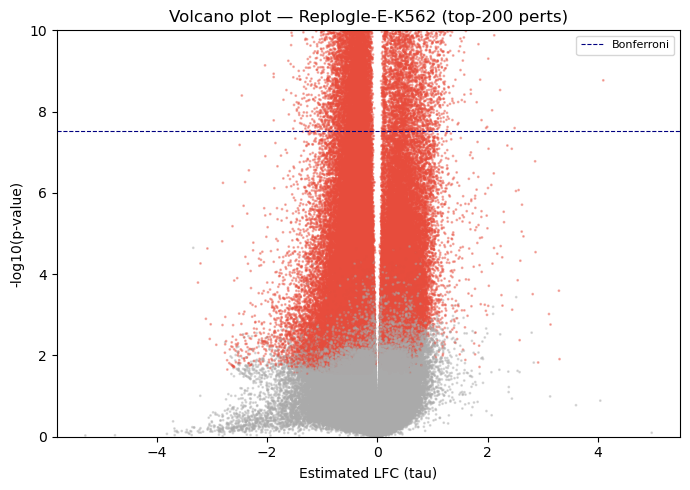

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = np.where(df_res['padj'] < FDR, '#e74c3c', '#aaaaaa')
ax.scatter(
    df_res['tau'], -np.log10(df_res['pvalue'].clip(1e-300)),
    c=colors, s=1, alpha=0.4, rasterized=True,
)
ax.axhline(-np.log10(0.05 / len(df_res)), color='navy', lw=0.8, ls='--',
           label='Bonferroni')
ax.set_ylim(0, 10)
ax.set_xlabel('Estimated LFC (tau)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano plot — Replogle-E-K562 (top-200 perts)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 6.2 Discovery count per perturbation

Each bar counts genes passing the BH-adjusted threshold for one perturbation. Differences can reflect biological response, sample size, expression support, or model fit; the counts alone do not distinguish these explanations.


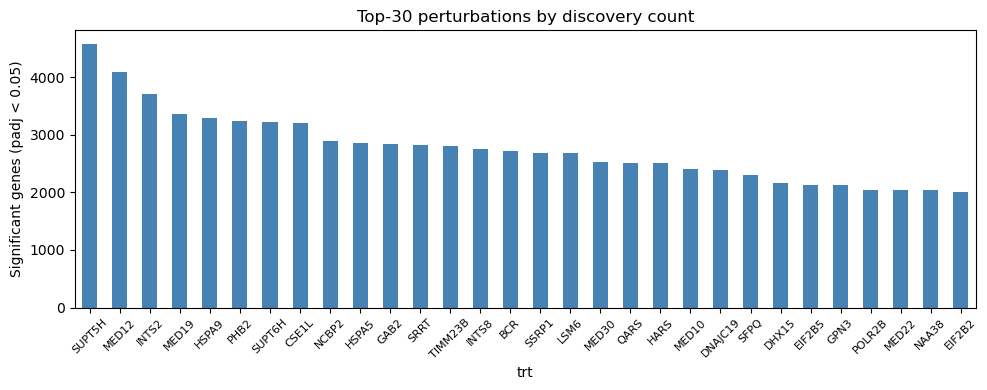

In [12]:
top_n = 30
top_disc = disc_per_pert.head(top_n)

fig, ax = plt.subplots(figsize=(10, 4))
top_disc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_ylabel(f'Significant genes (padj < {FDR})')
ax.set_title(f'Top-{top_n} perturbations by discovery count')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()


### 6.3 Comparison with a marginal Wilcoxon test

As a reference point, each perturbation is also compared with the pooled non-targeting
controls using a Wilcoxon rank-sum test on library-size-normalized, log1p counts
(via the optional `crispyx` package). Both methods are summarized at BH-adjusted
*p* < 0.05.

Wilcoxon is *marginal*: unlike causarray it adjusts for neither the observed covariates
nor the estimated latent factors. Gaps in discovery counts can therefore reflect
confounding, model assumptions, filtering, or power, and do not by themselves mark
discoveries as true or false.

In [13]:
import crispyx

# Wilcoxon is applied to normalized, log-transformed counts, following the
# same convention as the Adamson tutorial.
norm_path = Path('data/replogle_subset_norm.h5ad')
if not norm_path.exists():
    crispyx.normalize_total_log1p(
        'data/replogle_subset.h5ad', output_path=str(norm_path), verbose=False
    )
# The Wilcoxon result does not depend on causarray; cache it on disk and reuse
# it on later runs (crispyx skips the computation when the output exists).
wc_result = crispyx.wilcoxon_test(
    str(norm_path),
    perturbation_column=PERT_COL,
    control_label=CTRL_LABEL,
    verbose=False,
    output_path='results/replogle_subset_norm_cx_wilcoxon.h5ad',
)

wc_count_map = {
    str(pert): int((np.asarray(wc_result[pert].pvalue_adj) < FDR).sum())
    for pert in wc_result.groups
}
all_perts = pd.Index(A.columns.astype(str), name='Perturbation')
comparison_counts = pd.DataFrame(index=all_perts)
comparison_counts['causarray'] = (
    disc_per_pert.rename(index=str).reindex(all_perts, fill_value=0).astype(int)
)
comparison_counts['Wilcoxon'] = (
    pd.Series(wc_count_map).reindex(all_perts, fill_value=0).astype(int)
)
comparison_counts = comparison_counts.sort_values(
    ['Wilcoxon', 'causarray'], ascending=False
)

print(f'causarray: {comparison_counts["causarray"].sum():,} significant pairs')
print(f'Wilcoxon : {comparison_counts["Wilcoxon"].sum():,} significant pairs')
print('Median discoveries per perturbation: ' +
      f'causarray={comparison_counts["causarray"].median():.0f}, ' +
      f'Wilcoxon={comparison_counts["Wilcoxon"].median():.0f}')
display(comparison_counts.head(10))


causarray: 172,030 significant pairs
Wilcoxon : 425,125 significant pairs
Median discoveries per perturbation: causarray=488, Wilcoxon=2220


,causarray,Wilcoxon
Perturbation,,
SUPT5H,4584,6842
SUPT6H,3216,6476
MED12,4088,5883
MED30,2527,5458
INTS2,3701,5373
HSPA9,3290,5326
SFPQ,2295,5188
DDX41,356,5049
MED19,3358,4946


#### Comparing gene lists

The saved comparison reports more discoveries with Wilcoxon. To explore the difference, align results by perturbation and gene, then inspect direction-specific enrichment and expression support. Neither list size nor enrichment establishes which individual discoveries are correct.


In [14]:
wc_groups = pd.Index([str(group) for group in wc_result.groups], name='trt')
wc_genes = pd.Index(wc_result.genes.astype(str), name='gene_names')
wc_lfc = np.asarray(wc_result.logfoldchanges, dtype=float)
wc_padj = np.asarray(wc_result.pvalues_adj, dtype=float)
wc_pts_treated = np.asarray(wc_result.pts, dtype=float)
wc_pts_control = np.asarray(wc_result.pts_rest, dtype=float)

expected = pd.MultiIndex.from_product([wc_groups, wc_genes])
ca_indexed = (
    df_res.assign(
        trt=df_res['trt'].astype(str),
        gene_names=df_res['gene_names'].astype(str),
    ).set_index(['trt', 'gene_names'])
)
if ca_indexed.index.has_duplicates:
    raise ValueError('causarray contains duplicate perturbation-gene tests')
aligned_ca = ca_indexed.reindex(expected)
if aligned_ca['tau'].isna().all():
    raise ValueError('Wilcoxon and causarray results could not be aligned')

ca_lfc = (
    aligned_ca['tau'].to_numpy(dtype=float).reshape(wc_lfc.shape)
    / np.log(2.0)
)
ca_padj = aligned_ca['padj'].to_numpy(dtype=float).reshape(wc_lfc.shape)
ca_estimable = aligned_ca['estimable'].fillna(False).to_numpy().reshape(wc_lfc.shape)
wc_reject = wc_padj < FDR
ca_reject = ca_padj < FDR
del aligned_ca, ca_indexed, expected

print(f'Aligned {wc_lfc.size:,} perturbation-gene tests.')


Aligned 1,712,600 perturbation-gene tests.


#### Gene Ontology enrichment for SUPT5H

SUPT5H is the screen's canonical case: knocking down the SPT5 elongation factor should hit translation and ribosome biogenesis, so its gene list has a known expectation to be read against. It also carries the heaviest penalty of any arm, and the cell prints that alongside the result rather than leaving it implicit. Both methods are tested on the same gene background.

GO focus: SUPT5H -- penalty 1155x on log library size, overlap 0.00 -> 0.31, treated ESS 0.25
(92 arms needed no penalty at all and keep >= 80% of their treated sample)


,DE_genes,significant_GO_BP_terms
Wilcoxon down,5646,22
Wilcoxon up,1196,1
causarray down,4405,114
causarray up,179,0


,query,name,p_value,intersection_size,query_size
23,Wilcoxon down,ribosome biogenesis,8.496590e-13,249,5430
28,Wilcoxon down,ribonucleoprotein complex biogenesis,9.065321e-12,351,5430
38,Wilcoxon down,rRNA metabolic process,5.047599e-10,201,5430
45,Wilcoxon down,rRNA processing,3.027228e-09,178,5430
60,Wilcoxon down,translation,2.632631e-07,421,5430
134,Wilcoxon up,proton transmembrane transport,3.728893e-02,37,1124
0,causarray down,ribonucleoprotein complex biogenesis,7.093004e-35,344,4255
1,causarray down,translation,1.245411e-30,410,4255
2,causarray down,protein biosynthetic process,1.245411e-30,410,4255
4,causarray down,ribosome biogenesis,1.717395e-27,240,4255


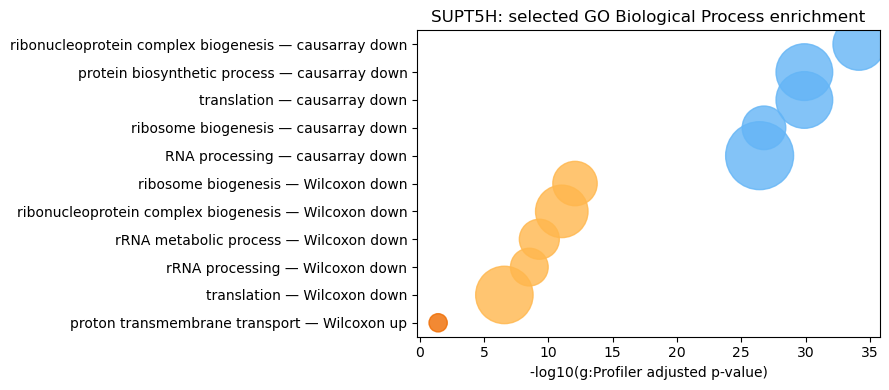

In [15]:
# SUPT5H is the screen's canonical case: knocking down the SPT5 elongation
# factor should hit translation and ribosome biogenesis. Its support is the
# weakest of the large arms, so the audit below is reported alongside it.
ps_audit = pd.read_csv('results/replogle_propensity_penalties.csv').set_index('treatment')
go_focus = 'SUPT5H'
_row = ps_audit.loc[go_focus]
print(f"GO focus: {go_focus} -- penalty {_row['penalty_factor']:.0f}x on log library size, "
      f"overlap {_row['overlap_before']:.2f} -> {_row['overlap_after']:.2f}, "
      f"treated ESS {_row['ess_treated_after']:.2f}")
_best = ps_audit[(ps_audit['penalty_factor'] == 1.0)
                 & (ps_audit['ess_treated_after'] >= 0.8)].index
print(f'({len(_best)} arms needed no penalty at all and keep >= 80% of their treated sample)')

go_result_path = Path(f'results/replogle_{go_focus.lower()}_go_results.csv')
focus_i = wc_groups.get_loc(go_focus)
go_queries = {
    'causarray up': wc_genes[ca_reject[focus_i] & (ca_lfc[focus_i] > 0)].tolist(),
    'causarray down': wc_genes[ca_reject[focus_i] & (ca_lfc[focus_i] < 0)].tolist(),
    'Wilcoxon up': wc_genes[wc_reject[focus_i] & (wc_lfc[focus_i] > 0)].tolist(),
    'Wilcoxon down': wc_genes[wc_reject[focus_i] & (wc_lfc[focus_i] < 0)].tolist(),
}
if go_result_path.exists():
    go_results = pd.read_csv(go_result_path)
else:
    go_results = sc.queries.enrich(
        go_queries, org='hsapiens',
        gprofiler_kwargs={
            'sources': ['GO:BP'],
            'background': wc_genes.tolist(),
            'no_evidences': False,
        },
    )
    go_results.to_csv(go_result_path, index=False)

go_query_summary = pd.DataFrame({
    'DE_genes': {query: len(genes) for query, genes in go_queries.items()},
    'significant_GO_BP_terms': (
        go_results.loc[go_results['significant']].groupby('query').size()
    ),
}).fillna(0).astype(int)
display(go_query_summary)

go_top = (
    go_results.loc[go_results['significant'] & go_results['term_size'].between(20, 1000)]
    .sort_values(['query', 'p_value'])
    .groupby('query', group_keys=False).head(5)
)
display(go_top[['query', 'name', 'p_value', 'intersection_size', 'query_size']])

if not go_top.empty:
    plotted = go_top.sort_values('p_value', ascending=False).copy()
    plotted['label'] = plotted['name'] + ' — ' + plotted['query']
    colors = plotted['query'].map({
        'causarray up': '#1976d2', 'causarray down': '#64b5f6',
        'Wilcoxon up': '#ef6c00', 'Wilcoxon down': '#ffb74d',
    })
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(plotted))))
    ax.scatter(
        -np.log10(plotted['p_value'].clip(1e-300)), plotted['label'],
        s=25 + 4 * plotted['intersection_size'], c=colors, alpha=0.8,
    )
    ax.set_xlabel('-log10(g:Profiler adjusted p-value)')
    ax.set_ylabel('')
    ax.set_title(f'{go_focus}: selected GO Biological Process enrichment')
    fig.tight_layout()
    plt.show()


In the saved enrichment results, both down-regulated lists highlight ribosome biogenesis and RNA-related processes; the up-regulated lists show less enrichment. This shared theme is more informative than comparing the number of significant terms. It does not establish that one method has fewer false discoveries.


#### Effect-size agreement and extreme Wilcoxon effects

Near-empty groups can produce large marginal log2 fold changes that depend strongly on the pseudocount. The full-range and zoomed panels show the tail and central agreement separately. Both axes use log2 units; colors indicate rejection at the chosen BH-adjusted threshold.


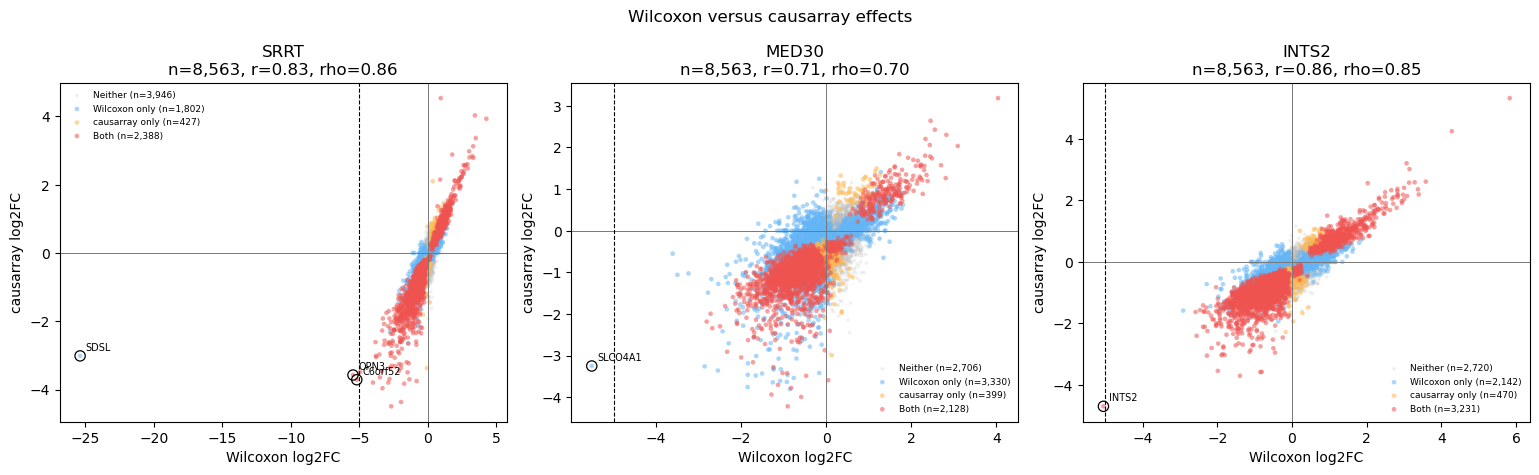

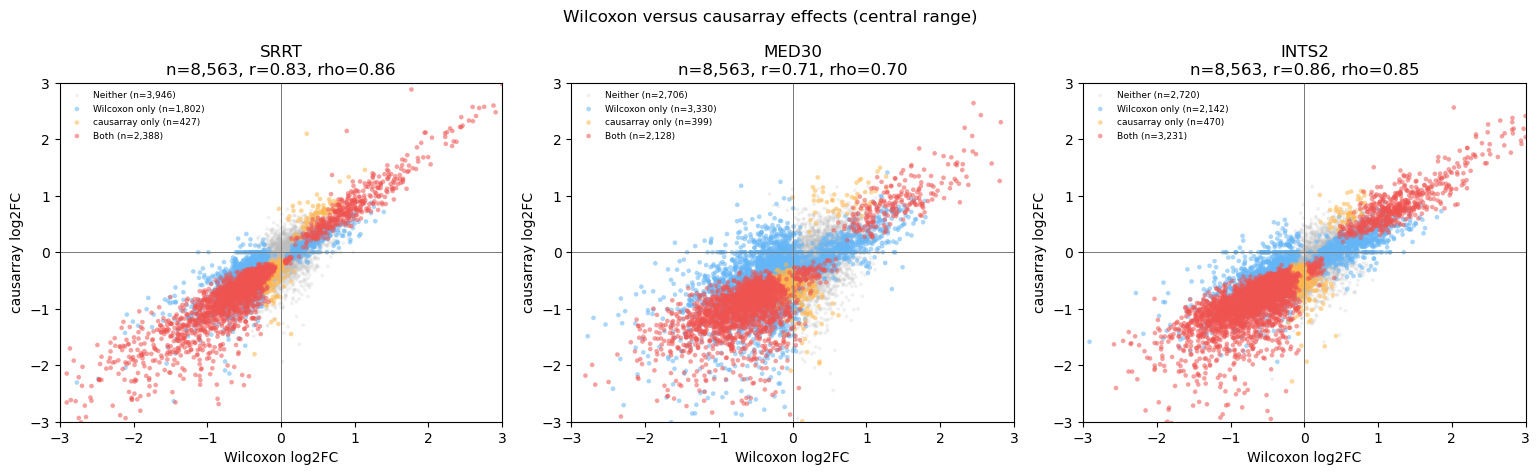

In [16]:
selected_perts = ['SRRT', 'MED30', 'INTS2']
category_colors = {
    'Neither': '#bdbdbd',
    'Wilcoxon only': '#64b5f6',
    'causarray only': '#ffb74d',
    'Both': '#ef5350',
}

def plot_lfc_comparison(limits=None):
    fig, axes = plt.subplots(1, len(selected_perts), figsize=(15.5, 4.8))
    for ax, perturbation in zip(axes, selected_perts):
        i = wc_groups.get_loc(perturbation)
        x, y = wc_lfc[i], ca_lfc[i]
        finite = np.isfinite(x) & np.isfinite(y)
        categories = np.select(
            [
                wc_reject[i] & ca_reject[i],
                wc_reject[i] & ~ca_reject[i],
                ~wc_reject[i] & ca_reject[i],
            ],
            ['Both', 'Wilcoxon only', 'causarray only'],
            default='Neither',
        )
        for category, color in category_colors.items():
            keep = finite & (categories == category)
            ax.scatter(
                x[keep], y[keep], s=7 if category == 'Neither' else 11,
                alpha=0.22 if category == 'Neither' else 0.55,
                color=color, edgecolors='none', rasterized=True,
                label=f'{category} (n={keep.sum():,})',
            )
        extreme = finite & (x < -5)
        if extreme.any():
            ax.scatter(
                x[extreme], y[extreme], s=55, facecolors='none',
                edgecolors='black', linewidths=0.9, zorder=5,
            )
            for gene, xv, yv in zip(wc_genes[extreme], x[extreme], y[extreme]):
                ax.annotate(gene, (xv, yv), xytext=(4, 4),
                            textcoords='offset points', fontsize=7)
        pearson = np.corrcoef(x[finite], y[finite])[0, 1]
        spearman = pd.Series(x[finite]).corr(pd.Series(y[finite]), method='spearman')
        ax.axhline(0, color='#777777', linewidth=0.7)
        ax.axvline(0, color='#777777', linewidth=0.7)
        ax.axvline(-5, color='black', linestyle='--', linewidth=0.8)
        if limits is not None:
            ax.set_xlim(limits)
            ax.set_ylim(limits)
        ax.set_title(
            f'{perturbation}\nn={finite.sum():,}, r={pearson:.2f}, rho={spearman:.2f}'
        )
        ax.set_xlabel('Wilcoxon log2FC')
        ax.set_ylabel('causarray log2FC')
        ax.legend(fontsize=6.5, frameon=False, loc='best')
    suffix = ' (central range)' if limits is not None else ''
    fig.suptitle('Wilcoxon versus causarray effects' + suffix)
    fig.tight_layout()
    return fig, axes

plot_lfc_comparison()
plt.show()
plot_lfc_comparison(limits=(-3, 3))
plt.show()


#### Inspecting the negative effect tail

The following diagnostic selects Wilcoxon log2 fold changes below a fixed display threshold and reports detection counts in each group. Direct targets are flagged to distinguish possible on-target depletion from other responses.


In [17]:
group_counts = adata.obs[PERT_COL].astype(str).value_counts()
treated_sizes = np.asarray([group_counts[group] for group in wc_groups])[:, None]
control_size = int(group_counts[CTRL_LABEL])
treated_detected = np.rint(wc_pts_treated * treated_sizes).astype(int)
control_detected = np.rint(wc_pts_control * control_size).astype(int)
extreme_positions = np.argwhere(wc_lfc < -5)

extreme_rows = []
for i, j in extreme_positions:
    if wc_reject[i, j] and ca_reject[i, j]:
        decision = 'Both'
    elif wc_reject[i, j]:
        decision = 'Wilcoxon only'
    elif ca_reject[i, j]:
        decision = 'causarray only'
    else:
        decision = 'Neither'
    extreme_rows.append({
        'perturbation': wc_groups[i],
        'gene': wc_genes[j],
        'direct_target': wc_groups[i] == wc_genes[j],
        'treated_detected': f'{treated_detected[i, j]}/{treated_sizes[i, 0]}',
        'control_detected': f'{control_detected[i, j]}/{control_size}',
        'Wilcoxon_log2FC': wc_lfc[i, j],
        'Wilcoxon_padj': wc_padj[i, j],
        'causarray_log2FC': ca_lfc[i, j],
        'causarray_padj': ca_padj[i, j],
        'causarray_estimable': bool(ca_estimable[i, j]),
        'decision': decision,
    })
extreme_tests = pd.DataFrame(extreme_rows).sort_values('Wilcoxon_log2FC')
display(extreme_tests.round({
    'Wilcoxon_log2FC': 3, 'Wilcoxon_padj': 3,
    'causarray_log2FC': 3, 'causarray_padj': 3,
}))


,perturbation,gene,direct_target,treated_detected,control_detected,Wilcoxon_log2FC,Wilcoxon_padj,causarray_log2FC,causarray_padj,causarray_estimable,decision
2,SRRT,SDSL,False,0/307,153/2000,-25.379,0.0,-3.014,0.078,True,Wilcoxon only
3,MED30,SLCO4A1,False,1/288,237/2000,-5.511,0.0,-3.250,0.258,True,Wilcoxon only
0,SRRT,OPN3,False,1/307,227/2000,-5.470,0.0,-3.574,0.033,True,Both
1,SRRT,C6orf52,False,1/307,246/2000,-5.193,0.0,-3.712,0.026,True,Both
4,INTS2,INTS2,True,3/354,517/2000,-5.048,0.0,-4.697,0.001,True,Both


#### Candidate support rules

Compare the candidate support rules before adopting one. Requiring detections in both groups removes near-empty comparisons but can also remove genuine complete knockouts. A higher-expression-group rule retains those cases, so it answers a different question. `align_test_mask` attaches a rule by label without refitting.


In [18]:
negative = wc_lfc < 0
higher_expression_detected = np.where(negative, control_detected, treated_detected)
higher_expression_size = np.where(negative, control_size, treated_sizes)
support_masks = {
    'both groups >= 1 detected':
        (treated_detected >= 1) & (control_detected >= 1),
    'both groups >= 3 detected':
        (treated_detected >= 3) & (control_detected >= 3),
    'both groups >= 5 detected':
        (treated_detected >= 5) & (control_detected >= 5),
    'both groups >= 10 detected':
        (treated_detected >= 10) & (control_detected >= 10),
    'both groups >= max(10, 1%)': (
        (treated_detected >= np.maximum(10, np.ceil(0.01 * treated_sizes)))
        & (control_detected >= max(10, int(np.ceil(0.01 * control_size))))
    ),
    'higher-expression group >= max(10, 1%)': (
        higher_expression_detected
        >= np.maximum(10, np.ceil(0.01 * higher_expression_size))
    ),
}

extreme_mask = wc_lfc < -5
rule_rows = []
for rule, keep in support_masks.items():
    removed = ~keep
    rule_rows.append({
        'rule': rule,
        'tests_removed': int(removed.sum()),
        'tests_removed_percent': 100 * removed.mean(),
        'extreme_tests_removed': int((removed & extreme_mask).sum()),
        'Wilcoxon_discoveries_removed': int((removed & wc_reject).sum()),
        'causarray_discoveries_removed': int((removed & ca_reject).sum()),
    })
support_rule_impact = pd.DataFrame(rule_rows)
display(support_rule_impact.round({'tests_removed_percent': 3}))

chosen_rule = 'higher-expression group >= max(10, 1%)'
keep_in_df_res = align_test_mask(
    df_res, support_masks[chosen_rule],
    treatment_names=wc_groups, gene_names=wc_genes,
)
print(f'{keep_in_df_res.sum():,}/{len(keep_in_df_res):,} causarray rows retained')
# Materialize only if needed; no LFC refit is performed:
# df_res_screened = df_res.loc[keep_in_df_res].copy()


,rule,tests_removed,tests_removed_percent,extreme_tests_removed,Wilcoxon_discoveries_removed,causarray_discoveries_removed
0,both groups >= 1 detected,1,0.000,1,1,0
1,both groups >= 3 detected,12,0.001,4,12,4
2,both groups >= 5 detected,41,0.002,5,37,13
3,both groups >= 10 detected,392,0.023,5,331,88
4,"both groups >= max(10, 1%)",392,0.023,5,331,88
5,"higher-expression group >= max(10, 1%)",9,0.001,0,0,0


1,712,591/1,712,600 causarray rows retained


#### Reading the support diagnostic

The saved extreme tail contains comparisons with few treated detections and better control support. This explains why a both-group rule removes more of the tail than a higher-expression-group rule. Inspect effect sizes, uncertainty, and raw support together rather than automatically discarding strong depletion.

These post hoc masks describe how the gene lists respond to a support rule, not a newly validated testing procedure. Keep the original adjusted p-values when displaying retained rows; filtering does not by itself establish FDR control within the selected subset.


## 7. Summary

Batch fitting makes a large perturbation screen manageable. The saved comparisons show that adjusted and marginal analyses can yield different gene lists while sharing enrichment themes. Expression-support checks help interpret extreme effects, and propensity diagnostics reveal weight concentration that discovery counts alone miss.

Report the selected model, the support rules, and the per-arm penalties together. Recheck these qualitative patterns whenever the analysis or caches are refreshed.
